In [134]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

options = {"thermal": "lumped"}

## Model for NVPF/HC sodium ion battery only

In [135]:
model = pybamm.sodium_ion.BasicDFN()

In [136]:
parameter_values = pybamm.ParameterValues("Chayambuka2022")

In [137]:
# Cell design specific parameters to be updated using values from the cell design tool
# For sodium Std. 18650 from Mahesh's thesis
parameter_values.update({
                        "Negative electrode thickness [m]": 64e-6,
                        "Negative electrode porosity": 0.51,
                        "Negative electrode active material volume fraction": 0.489,
                        
                        
                        "Separator thickness [m]": 25e-6,
                        "Separator porosity": 0.54,
                        
                        "Positive electrode thickness [m]": 68e-6,
                        "Positive electrode porosity": 0.22,
                        "Positive electrode active material volume fraction": 0.55,
                        
                        #use the lesser values of (cathode, anode)
                        "Electrode height [m]": 60e-3, 
                        "Electrode width [m]": 561e-3,
                         
                        "Nominal cell capacity [A.h]": 0.93,
                        "Current function [A]": 0.93,
                        "Contact resistance [Ohm]": 0.001,
                        "Cell volume [m3]": 16.5e-06,
                        
                        },check_already_exists=False)

parameter_values.update({
                        
                        "Maximum concentration in negative electrode [mol.m-3]": 14540, #to be calculated from mAh/g
                        "Maximum concentration in positive electrode [mol.m-3]": 15320, #to be calculated from mAh/g
                        # leave it to default values for now
                        })


In [138]:
C_rates_in = 1

In [139]:
sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=C_rates_in)
sim.solve([0, 3600/C_rates_in])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=706.0790954263506, step=7.060790954263506), …

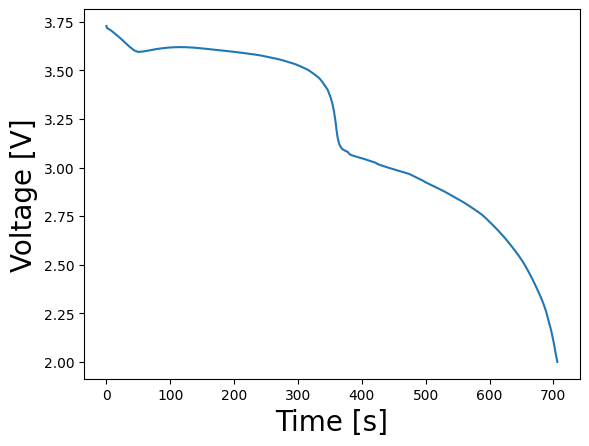

Text(0, 0.5, 'Voltage [V]')

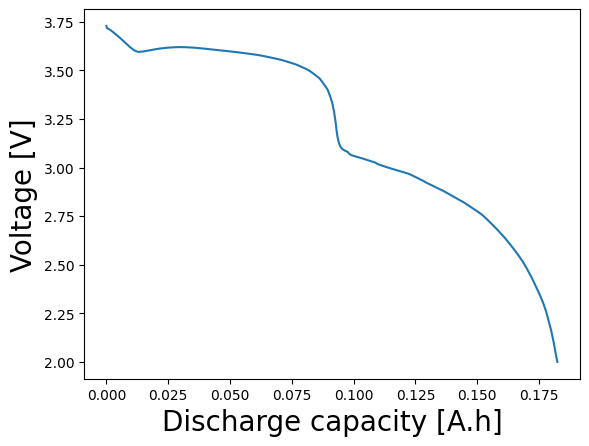

In [140]:
t1 = sim.solution["Time [s]"].entries
Vc1 = sim.solution["Battery voltage [V]"].entries
Qd1 = sim.solution["Discharge capacity [A.h]"].entries


plt.plot(t1, Vc1)
plt.xlabel("Time [s]",fontsize=20)
#plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)
plt.show()
plt.plot(Qd1,Vc1)
#plt.xlabel("Time [h]",fontsize=20)
plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)